In [1]:
pip install kaggle

In [2]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [3]:
!kaggle datasets download -d apollo2506/eurosat-dataset

Dataset URL: https://www.kaggle.com/datasets/apollo2506/eurosat-dataset
License(s): CC0-1.0
100% 2.04G/2.04G [00:13<00:00, 167MB/s]



In [4]:
import zipfile

with zipfile.ZipFile("eurosat-dataset.zip", 'r') as zip_ref:
    zip_ref.extractall("eurosat_data")

In [5]:
import os

for root, dirs, files in os.walk("eurosat_data"):
    print(root)
    break

eurosat_data


In [6]:
!pip install kaggle rasterio pyspark

In [7]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("EuroSAT NDVI Analysis") \
    .getOrCreate()

In [8]:
import os

base_path = "eurosat_data/EuroSATallBands"

data = []

for class_name in os.listdir(base_path):
    class_path = os.path.join(base_path, class_name)

    if os.path.isdir(class_path):
        for file in os.listdir(class_path):
            if file.endswith(".tif"):
                data.append((os.path.join(class_path, file), class_name))

print("Total images:", len(data))

Total images: 27597


In [100]:
rdd = spark.sparkContext.parallelize(data)

In [101]:
def compute_ndvi(record):
    import rasterio
    import numpy as np

    file_path, label = record

    try:
        with rasterio.open(file_path) as ds:

            red = ds.read(4).astype(float)
            nir = ds.read(8).astype(float)


            if red.max() > 1:
                red = red / 10000.0
                nir = nir / 10000.0

            ndvi = (nir - red) / (nir + red + 1e-10)

            ndvi = ndvi[np.isfinite(ndvi)]
            ndvi = ndvi[(ndvi >= -1) & (ndvi <= 1)]

            if len(ndvi) == 0:
              return (
                  file_path,label,None,None,None,None)


            mean_ndvi = float(np.mean(ndvi))
            std_ndvi = float(np.std(ndvi))
            min_ndvi = float(np.min(ndvi))
            max_ndvi = float(np.max(ndvi))

            return (
                file_path,
                label,
                mean_ndvi,
                std_ndvi,
                min_ndvi,
                max_ndvi
            )

    except Exception:
        return (file_path, label,None,None,None,None)

In [102]:
ndvi_rdd = (
    rdd
    .map(compute_ndvi)
    .filter(lambda x: x is not None)
)

print("Valid images =", ndvi_rdd.count())

Valid images = 27597


In [103]:
columns = [
    "Image_Path",
    "Class",
    "Mean_NDVI",
    "Std_NDVI",
    "Min_NDVI",
    "Max_NDVI"
]

df = spark.createDataFrame(ndvi_rdd, columns)

df.show(5)

+--------------------+--------------------+-------------------+--------------------+--------------------+------------------+
|          Image_Path|               Class|          Mean_NDVI|            Std_NDVI|            Min_NDVI|          Max_NDVI|
+--------------------+--------------------+-------------------+--------------------+--------------------+------------------+
|eurosat_data/Euro...|HerbaceousVegetation|0.28442240133323915| 0.05920797655157032| 0.14607715644861788|0.5245161288630594|
|eurosat_data/Euro...|HerbaceousVegetation|0.26115420944284246| 0.06782939098315538|-0.01978691016775...|0.5005537097174547|
|eurosat_data/Euro...|HerbaceousVegetation|0.10577730184578203| 0.12177908583676597|-0.21384928673350445|0.5505359875380796|
|eurosat_data/Euro...|HerbaceousVegetation| 0.4855186804482879| 0.06323381593535085| 0.23260025867203102|0.6395280234101688|
|eurosat_data/Euro...|HerbaceousVegetation|0.22059283675296043|0.051165566532381974|0.024714434055095637|0.4186503602492574|


In [104]:
from pyspark.sql.functions import avg, stddev

class_stats = (
    df.groupBy("Class")
    .agg(
        avg("Mean_NDVI").alias("Mean_NDVI"),
        stddev("Mean_NDVI").alias("Std_NDVI")
    )
    .orderBy("Mean_NDVI", ascending=False)
)

class_stats.show()

+--------------------+--------------------+-------------------+
|               Class|           Mean_NDVI|           Std_NDVI|
+--------------------+--------------------+-------------------+
|              Forest|  0.7130055350373479|0.07265255317105908|
|             Pasture|   0.653781684190193|0.10265873724312122|
|             Highway|   0.446230542038038|0.15848887621747437|
|HerbaceousVegetation| 0.38496088053990435|0.14747576104218055|
|          AnnualCrop| 0.37640977279824406|  0.158939877706198|
|       PermanentCrop| 0.37204797455540933| 0.1207063952253926|
|         Residential|  0.3395045980115247| 0.1108306732437176|
|               River|  0.3273605237885086| 0.1805222210235751|
|          Industrial| 0.22276097347533527|0.09554466422101442|
|             SeaLake|-0.24709807857300167|0.12212700537499321|
+--------------------+--------------------+-------------------+



In [93]:
stats_pd = class_stats.toPandas()

stats_pd

,Class,Mean_NDVI,Std_NDVI
0,Forest,0.713006,0.072653
1,Pasture,0.653782,0.102659
2,Highway,0.446231,0.158489
3,HerbaceousVegetation,0.384961,0.147476
4,AnnualCrop,0.376410,0.158940
5,PermanentCrop,0.372048,0.120706
6,Residential,0.339505,0.110831
7,River,0.327361,0.180522
8,Industrial,0.222761,0.095545
9,SeaLake,-0.247098,0.122127


In [94]:
metadata_pd = df.toPandas()

metadata_pd.to_csv(
    "metadata.csv",
    index=False
)

print("Metadata exported successfully.")

Metadata exported successfully.


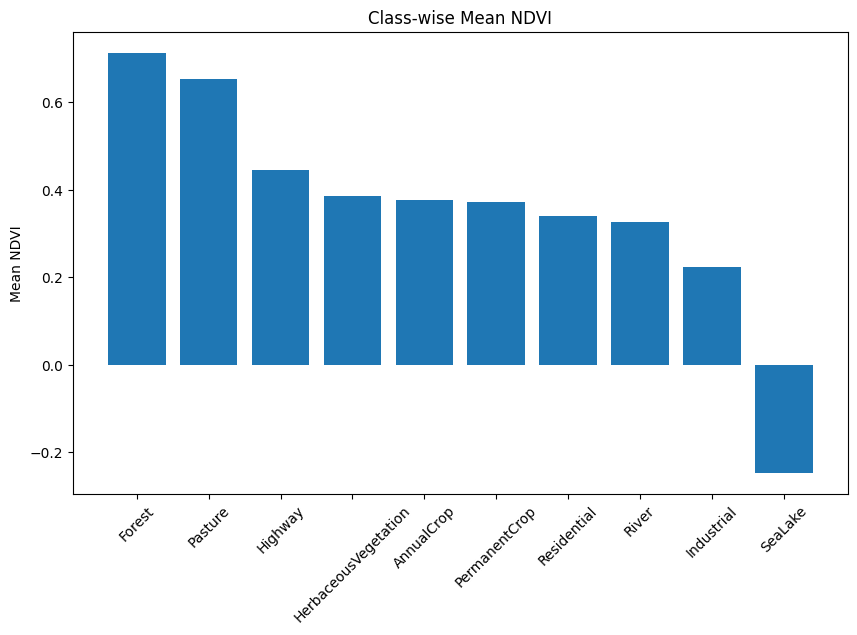

In [95]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.bar(
    stats_pd["Class"],
    stats_pd["Mean_NDVI"]
)

plt.xticks(rotation=45)
plt.ylabel("Mean NDVI")
plt.title("Class-wise Mean NDVI")

plt.show()

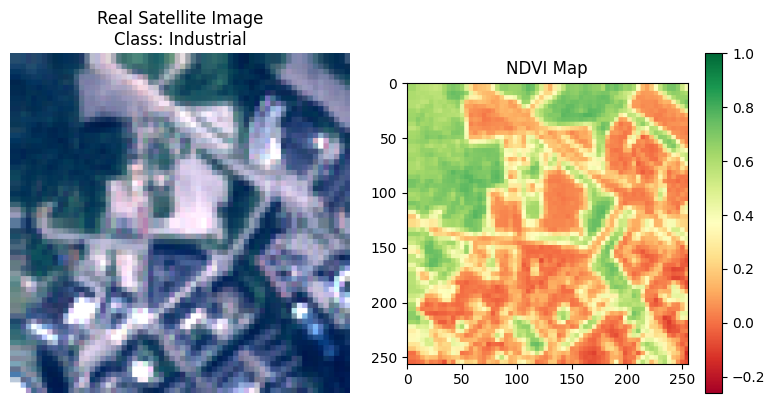

In [149]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
import cv2

file_path, label = data[23000]

with rasterio.open(file_path) as ds:
    blue = ds.read(2).astype(float)
    green = ds.read(3).astype(float)
    red = ds.read(4).astype(float)
    nir = ds.read(8).astype(float)

if red.max() > 1:
    blue /= 10000.0
    green /= 10000.0
    red /= 10000.0
    nir /= 10000.0

rgb = np.dstack((red, green, blue))

p2, p98 = np.percentile(rgb, (2, 98))
rgb = (rgb - p2) / (p98 - p2 + 1e-10)
rgb = np.clip(rgb, 0, 1)

ndvi = (nir - red) / (nir + red + 1e-10)
ndvi = np.clip(ndvi, -1, 1)

scale_size = 256

rgb_up = cv2.resize(rgb, (scale_size, scale_size), interpolation=cv2.INTER_NEAREST)
ndvi_up = cv2.resize(ndvi, (scale_size, scale_size), interpolation=cv2.INTER_NEAREST)
plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(rgb_up)
plt.title(f"Real Satellite Image\nClass: {label}")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(ndvi_up, cmap='RdYlGn', vmin=-0.26, vmax=1)  #keeping -0.26 for better visualization (generally its -1)
plt.title("NDVI Map")
plt.colorbar()

plt.tight_layout()
plt.show()

Selected: eurosat_data/EuroSATallBands/AnnualCrop/AnnualCrop_2377.tif


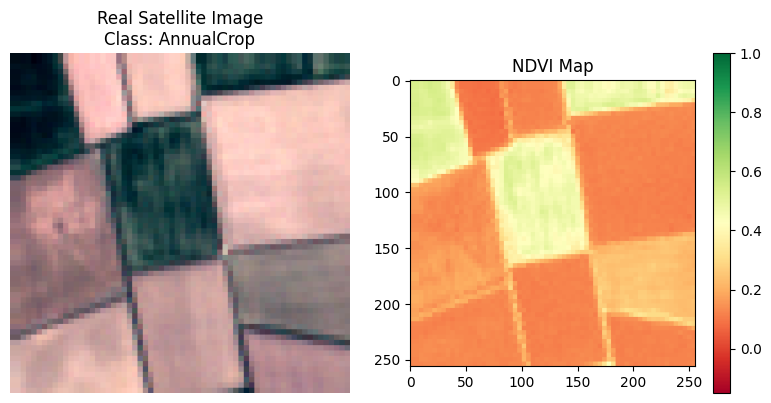

In [ ]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt

selected_class = "AnnualCrop"
image_number = 100

count = 0

for item in data:
    if item[1] == selected_class:
        count += 1
        if count == image_number:
            file_path, label = item
            break

print("Selected:", file_path)

with rasterio.open(file_path) as ds:
    blue = ds.read(2).astype(float)
    green = ds.read(3).astype(float)
    red = ds.read(4).astype(float)
    nir = ds.read(8).astype(float)

if red.max() > 1:
    blue /= 10000.0
    green /= 10000.0
    red /= 10000.0
    nir /= 10000.0

rgb = np.dstack((red, green, blue))

p2, p98 = np.percentile(rgb, (2, 98))
rgb = (rgb - p2) / (p98 - p2 + 1e-10)
rgb = np.clip(rgb, 0, 1)


ndvi = (nir - red) / (nir + red + 1e-10)
ndvi = np.clip(ndvi, -1, 1)

scale_size = 256

rgb_up = cv2.resize(rgb, (scale_size, scale_size), interpolation=cv2.INTER_NEAREST)
ndvi_up = cv2.resize(ndvi, (scale_size, scale_size), interpolation=cv2.INTER_NEAREST)

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(rgb_up)
plt.title(f"Real Satellite Image\nClass: {label}")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(ndvi_up, cmap='RdYlGn', vmin=-0.15, vmax=1)    #keeping -0.15 for better visualization (generally its -1)
plt.title("NDVI Map")
plt.colorbar()

plt.tight_layout()
plt.show()

## 10% Dataset

In [105]:
sample_df = df.sample(fraction=0.1, seed=42)   # 10% data
pdf = sample_df.toPandas()

In [106]:
rdd = spark.sparkContext.parallelize(data, 8)

sample_rdd = rdd.sample(False, 0.2)

ndvi_rdd = sample_rdd.map(compute_ndvi).cache()

In [107]:
clean_rdd = ndvi_rdd.filter(lambda x: x[2] is not None)

In [108]:
df.cache()
df.count()

27597

In [120]:
class_stats = (
    sample_df.groupBy("Class")
      .agg(
          avg("Mean_NDVI").alias("Mean_NDVI"),
          stddev("Mean_NDVI").alias("Std_NDVI"),
          min("Mean_NDVI").alias("Min_NDVI"),
          max("Mean_NDVI").alias("Max_NDVI")
      )
      .orderBy("Mean_NDVI", ascending=False)
)

class_stats.show()

+--------------------+--------------------+-------------------+--------------------+-------------------+
|               Class|           Mean_NDVI|           Std_NDVI|            Min_NDVI|           Max_NDVI|
+--------------------+--------------------+-------------------+--------------------+-------------------+
|              Forest|  0.7138148607573609|0.07286628678295025| 0.41879694011255136| 0.8255638144223727|
|             Pasture|  0.6560846973873499|0.10543397462411709|  0.1993615864826421| 0.8178356830173434|
|             Highway|  0.4404192182821107|0.16064210143254043|-0.06675003452658017| 0.7650581148697054|
|HerbaceousVegetation|  0.3891557765920552|0.14361077072642747| 0.02955135442852044| 0.7066718585126953|
|          AnnualCrop|  0.3835160129903157|0.16333978769694762| 0.05894076838793025| 0.8138554770609245|
|       PermanentCrop| 0.37165526619543154|0.12036815684662257|   0.139978173336165| 0.6536024240891568|
|         Residential|  0.3344525340691321|0.1182877429

In [122]:
from pyspark.sql.functions import when

ndvi_category_df = df.withColumn(
    "NDVI_Level",
    when(df.Mean_NDVI <= 0, "Low")
    .when((df.Mean_NDVI > 0) & (df.Mean_NDVI <= 0.3), "Medium")
    .otherwise("High")
)

In [123]:
ndvi_category_df.groupBy("NDVI_Level").count().show()

+----------+-----+
|NDVI_Level|count|
+----------+-----+
|      High|16535|
|       Low| 3573|
|    Medium| 7489|
+----------+-----+



In [124]:
ndvi_category_df.groupBy("Class", "NDVI_Level").count().show()

+--------------------+----------+-----+
|               Class|NDVI_Level|count|
+--------------------+----------+-----+
|             Highway|    Medium|  483|
|              Forest|      High| 2996|
|       PermanentCrop|    Medium|  856|
|             Highway|       Low|    1|
|             SeaLake|       Low| 3479|
|       PermanentCrop|      High| 1644|
|HerbaceousVegetation|      High| 2013|
|HerbaceousVegetation|    Medium|  986|
|HerbaceousVegetation|       Low|    1|
|             Highway|      High| 2016|
|             SeaLake|    Medium|  118|
|              Forest|    Medium|    4|
|          AnnualCrop|    Medium| 1079|
|          Industrial|    Medium| 1969|
|             Pasture|      High| 1992|
|         Residential|       Low|    2|
|          AnnualCrop|      High| 1921|
|               River|    Medium| 1005|
|          Industrial|      High|  527|
|               River|       Low|   86|
+--------------------+----------+-----+
only showing top 20 rows


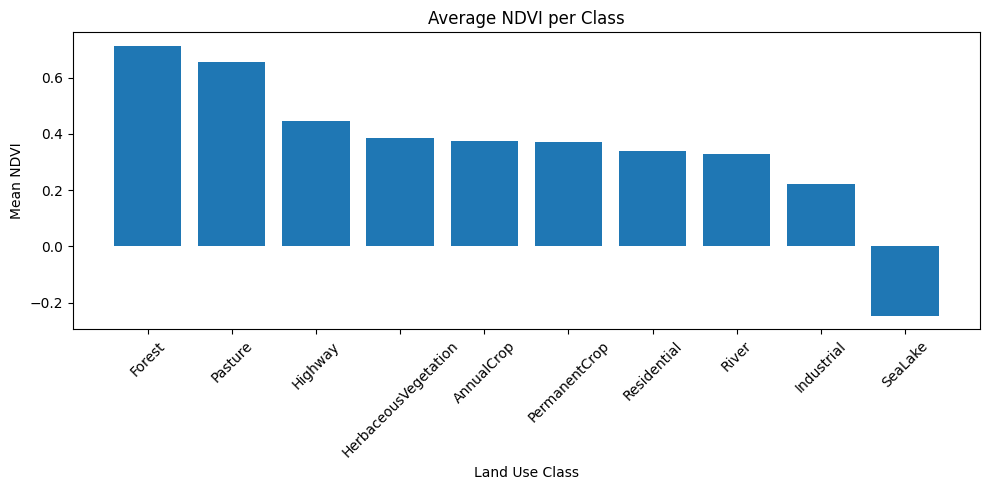

In [127]:
from pyspark.sql.functions import avg

pdf = (
    df.groupBy("Class")
      .agg(avg("Mean_NDVI").alias("Mean_NDVI"))
      .toPandas()
)

import matplotlib.pyplot as plt

pdf = pdf.sort_values(
    by="Mean_NDVI",
    ascending=False
)

plt.figure(figsize=(10,5))

plt.bar(
    pdf["Class"],
    pdf["Mean_NDVI"]
)

plt.xticks(rotation=45)
plt.ylabel("Mean NDVI")
plt.xlabel("Land Use Class")
plt.title("Average NDVI per Class")

plt.tight_layout()

plt.show()

In [129]:
df.orderBy("Mean_NDVI", ascending=False).show(5)

+--------------------+-------+------------------+--------------------+-------------------+------------------+
|          Image_Path|  Class|         Mean_NDVI|            Std_NDVI|           Min_NDVI|          Max_NDVI|
+--------------------+-------+------------------+--------------------+-------------------+------------------+
|eurosat_data/Euro...|Pasture|0.8385463739328098| 0.04214910192674653|0.49837556838909164|0.8856249998616212|
|eurosat_data/Euro...|Pasture|0.8384225881419693| 0.03603218738434543| 0.4169040834717701|0.8771901095665319|
|eurosat_data/Euro...|Pasture|0.8379039089809253|0.034807451423146805| 0.5317426500784528| 0.884057970865511|
|eurosat_data/Euro...|Pasture|0.8354991180579507| 0.05063715774354582|0.37700865254109744|0.8763244744004995|
|eurosat_data/Euro...| Forest|0.8346434377927154|0.022399822680598782| 0.6481306941099181|0.8661170002225919|
+--------------------+-------+------------------+--------------------+-------------------+------------------+
only showi

In [130]:
df.orderBy("Mean_NDVI", ascending=True).show(5)

+--------------------+-------+-------------------+--------------------+-------------------+-------------------+
|          Image_Path|  Class|          Mean_NDVI|            Std_NDVI|           Min_NDVI|           Max_NDVI|
+--------------------+-------+-------------------+--------------------+-------------------+-------------------+
|eurosat_data/Euro...|SeaLake|-0.5883271629708906|0.007391376189419218| -0.613472333108683|-0.5599060293187893|
|eurosat_data/Euro...|SeaLake|-0.5874668794592619|0.007622919128732...|-0.6170212760908173|-0.5505617973109457|
|eurosat_data/Euro...|SeaLake|-0.5811152378878247|0.007114835384412559|-0.6123642434316089|-0.5559183668931279|
|eurosat_data/Euro...|SeaLake|-0.5804119022653546|0.007645913862753...|-0.6235864292216589|-0.5476550676644061|
|eurosat_data/Euro...|SeaLake|-0.5788958464819154|0.007663066502029482|-0.6101829748526785| -0.545045044635852|
+--------------------+-------+-------------------+--------------------+-------------------+-------------

# Full Dataset

In [131]:
rdd = spark.sparkContext.parallelize(data, 8)

In [132]:
ndvi_rdd = rdd.map(compute_ndvi).cache()

In [133]:
clean_rdd = ndvi_rdd.filter(lambda x: x[2] is not None)

In [134]:
df.cache()
df.count()

27597

In [135]:
class_stats = (
    df.groupBy("Class")
      .agg(
          avg("Mean_NDVI").alias("Mean_NDVI"),
          stddev("Mean_NDVI").alias("Std_NDVI"),
          min("Mean_NDVI").alias("Min_NDVI"),
          max("Mean_NDVI").alias("Max_NDVI")
      )
      .orderBy("Mean_NDVI", ascending=False)
)

class_stats.show()

+--------------------+--------------------+-------------------+--------------------+-------------------+
|               Class|           Mean_NDVI|           Std_NDVI|            Min_NDVI|           Max_NDVI|
+--------------------+--------------------+-------------------+--------------------+-------------------+
|              Forest|  0.7130055350373479|0.07265255317105908| 0.25983706771545945| 0.8346434377927154|
|             Pasture|   0.653781684190193|0.10265873724312122| 0.16496096820271383| 0.8385463739328098|
|             Highway|   0.446230542038038|0.15848887621747437|-0.06675003452658017|  0.768021199525126|
|HerbaceousVegetation| 0.38496088053990435|0.14747576104218055|-0.00784452895302...| 0.7736061146765696|
|          AnnualCrop| 0.37640977279824406|  0.158939877706198| 0.05894076838793025| 0.8274815710012036|
|       PermanentCrop| 0.37204797455540933| 0.1207063952253926| 0.10621661120170697| 0.7098594074721576|
|         Residential|  0.3395045980115247| 0.110830673

In [137]:
from pyspark.sql.functions import when

ndvi_category_df = df.withColumn(
    "NDVI_Level",
    when(df.Mean_NDVI <= 0, "Low")
    .when((df.Mean_NDVI > 0) & (df.Mean_NDVI <= 0.3), "Medium")
    .otherwise("High")
)

ndvi_category_df.groupBy("NDVI_Level").count().show()

+----------+-----+
|NDVI_Level|count|
+----------+-----+
|      High|16535|
|       Low| 3573|
|    Medium| 7489|
+----------+-----+



In [138]:
df.write.csv("final_ndvi_results", header=True)

In [ ]:
import shutil

shutil.make_archive("ndvi_results", 'zip', "final_ndvi_results")

'/content/ndvi_results.zip'

In [ ]:
from google.colab import files
files.download("ndvi_results.zip")

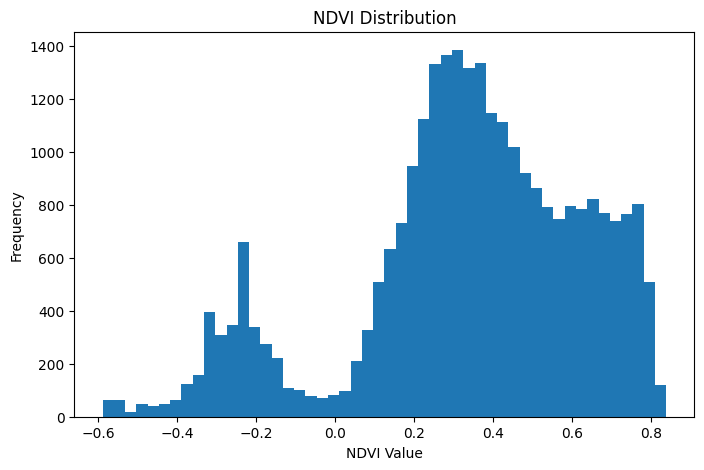

In [143]:
pdf = df.select("Mean_NDVI").toPandas()

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(pdf["Mean_NDVI"], bins=50)
plt.title("NDVI Distribution")
plt.xlabel("NDVI Value")
plt.ylabel("Frequency")
plt.show()

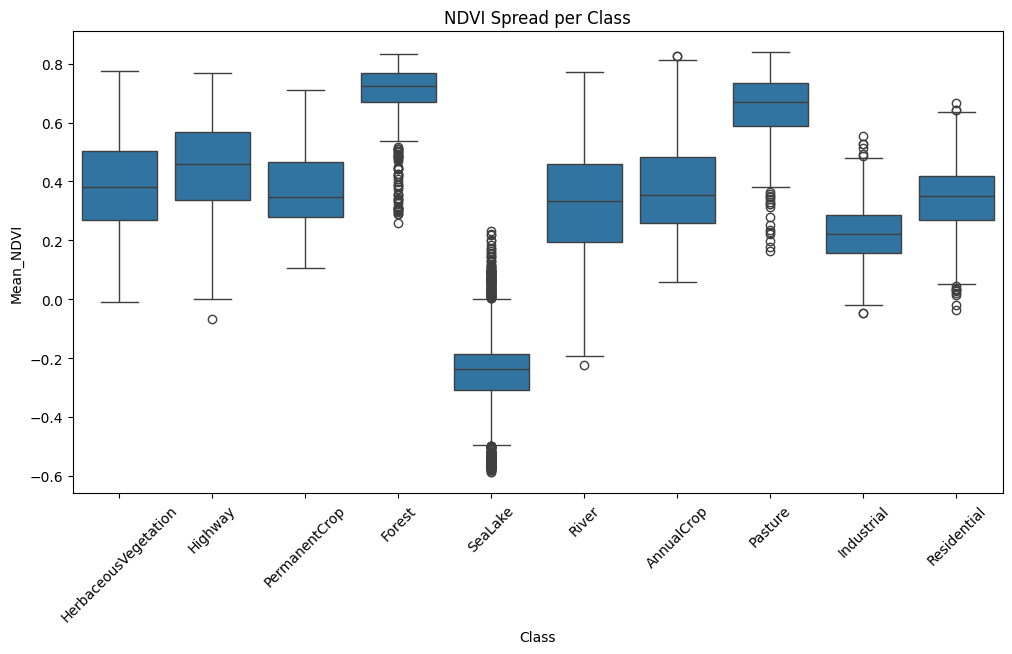

In [141]:
pdf = df.toPandas()

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
sns.boxplot(x="Class", y="Mean_NDVI", data=pdf)
plt.xticks(rotation=45)
plt.title("NDVI Spread per Class")
plt.show()

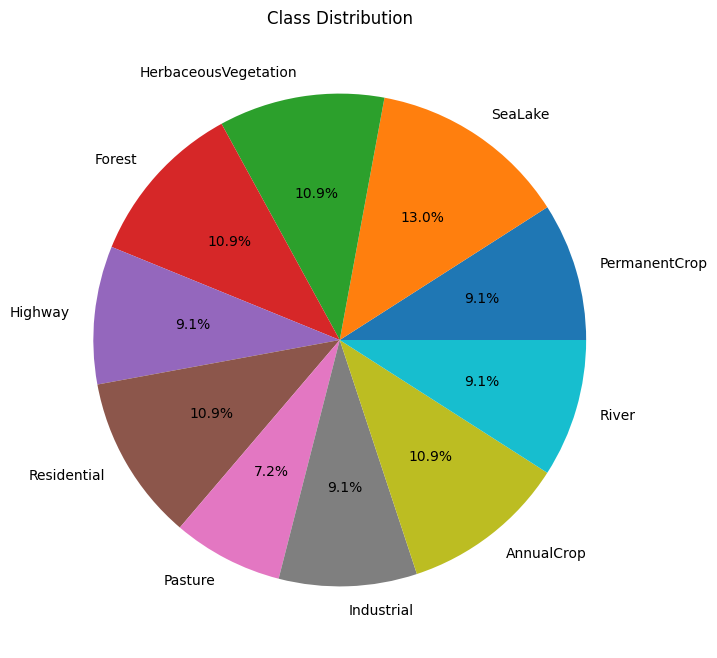

In [144]:
pdf2 = df.groupBy("Class").count().toPandas()

plt.figure(figsize=(8,8))
plt.pie(pdf2["count"], labels=pdf2["Class"], autopct='%1.1f%%')
plt.title("Class Distribution")
plt.show()

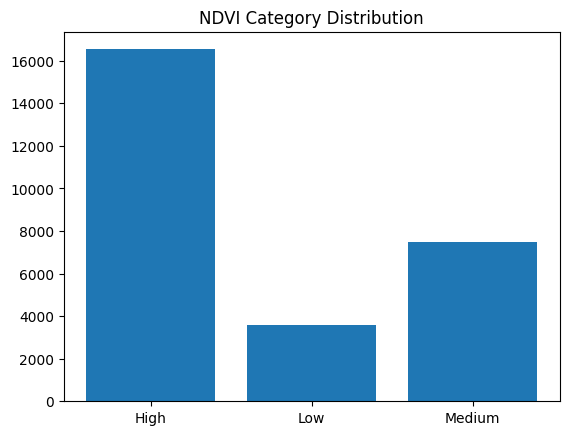

In [145]:
pdf3 = ndvi_category_df.groupBy("NDVI_Level").count().toPandas()

plt.bar(pdf3["NDVI_Level"], pdf3["count"])
plt.title("NDVI Category Distribution")
plt.show()

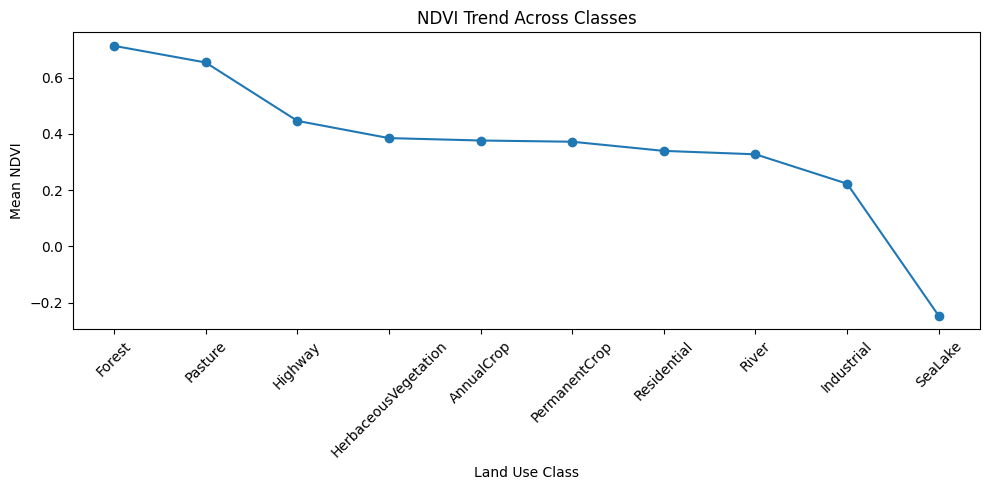

In [147]:
from pyspark.sql.functions import avg

pdf4 = (
    df.groupBy("Class")
      .agg(avg("Mean_NDVI").alias("Mean_NDVI"))
      .toPandas()
)

pdf4 = pdf4.sort_values(
    by="Mean_NDVI",
    ascending=False
)

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(
    pdf4["Class"],
    pdf4["Mean_NDVI"],
    marker='o'
)

plt.xticks(rotation=45)
plt.xlabel("Land Use Class")
plt.ylabel("Mean NDVI")
plt.title("NDVI Trend Across Classes")

plt.tight_layout()

plt.show()

In [ ]:
import os
import rasterio
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import shutil

output_base = "/content/ndvi_dataset"
rgb_folder = os.path.join(output_base, "rgb")
ndvi_folder = os.path.join(output_base, "ndvi")

os.makedirs(rgb_folder, exist_ok=True)
os.makedirs(ndvi_folder, exist_ok=True)

def process_and_save(file_path, label, idx):
    try:
        with rasterio.open(file_path) as ds:
            blue = ds.read(2).astype(float)
            green = ds.read(3).astype(float)
            red = ds.read(4).astype(float)
            nir = ds.read(8).astype(float)

        if red.max() > 1:
            blue /= 10000.0
            green /= 10000.0
            red /= 10000.0
            nir /= 10000.0

        rgb = np.dstack((red, green, blue))
        p2, p98 = np.percentile(rgb, (2, 98))
        rgb = (rgb - p2) / (p98 - p2 + 1e-10)
        rgb = np.clip(rgb, 0, 1)

        ndvi = (nir - red) / (nir + red + 1e-10)
        ndvi = np.clip(ndvi, -1, 1)

        base_name = os.path.splitext(os.path.basename(file_path))[0]

        rgb_path = os.path.join(rgb_folder, f"{base_name}.png")
        plt.imsave(rgb_path, rgb)

        ndvi_path = os.path.join(ndvi_folder, f"{base_name}_ndvi.png")
        plt.imsave(ndvi_path, ndvi, cmap='RdYlGn', vmin=-0.26, vmax=1)  ##keeping -0.26 for better visualization (generally its -1)

    except Exception as e:
        print(f"Error in {file_path}: {e}")

for i, (file_path, label) in enumerate(tqdm(data)):
    process_and_save(file_path, label, i)

print("All images processed!")

zip_path = "/content/ndvi_dataset.zip"
shutil.make_archive("/content/ndvi_dataset", 'zip', output_base)

print("ZIP file created!")
print("Download from:", zip_path)

100%|██████████| 27597/27597 [04:26<00:00, 103.62it/s]


All images processed!
ZIP file created!
Download from: /content/ndvi_dataset.zip


In [ ]:
import os
import rasterio
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import shutil

output_base = "/content/ndvi_dataset"
rgb_folder = os.path.join(output_base, "rgb")
ndvi_folder = os.path.join(output_base, "ndvi")

os.makedirs(rgb_folder, exist_ok=True)
os.makedirs(ndvi_folder, exist_ok=True)

def process_and_save(file_path, label, idx):
    try:
        with rasterio.open(file_path) as ds:
            blue = ds.read(2).astype(float)
            green = ds.read(3).astype(float)
            red = ds.read(4).astype(float)
            nir = ds.read(8).astype(float)

        if red.max() > 1:
            blue /= 10000.0
            green /= 10000.0
            red /= 10000.0
            nir /= 10000.0

        rgb = np.dstack((red, green, blue))
        p2, p98 = np.percentile(rgb, (2, 98))
        rgb = (rgb - p2) / (p98 - p2 + 1e-10)
        rgb = np.clip(rgb, 0, 1)


        ndvi = (nir - red) / (nir + red + 1e-10)
        ndvi = np.clip(ndvi, -1, 1)

        rgb_class_folder = os.path.join(rgb_folder, label)
        ndvi_class_folder = os.path.join(ndvi_folder, label)

        os.makedirs(rgb_class_folder, exist_ok=True)
        os.makedirs(ndvi_class_folder, exist_ok=True)

        base_name = os.path.splitext(os.path.basename(file_path))[0]

        rgb_path = os.path.join(rgb_class_folder, f"{base_name}.png")
        plt.imsave(rgb_path, rgb)

        ndvi_path = os.path.join(ndvi_class_folder, f"{base_name}_ndvi.png")
        plt.imsave(ndvi_path, ndvi, cmap='RdYlGn', vmin=-0.26, vmax=1)     #keeping -0.26 for better visualization (generally its -1)

    except Exception as e:
        print(f"Error in {file_path}: {e}")

for i, (file_path, label) in enumerate(tqdm(data)):
    process_and_save(file_path, label, i)

print("All images processed!")

zip_path = "/content/ndvi_dataset.zip"
shutil.make_archive("/content/ndvi_dataset", 'zip', output_base)

print("ZIP file created!")
print("Download from:", zip_path)

from google.colab import files
files.download(zip_path)


100%|██████████| 27597/27597 [04:03<00:00, 113.34it/s]


All images processed!
ZIP file created!
Download from: /content/ndvi_dataset.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>